<a href="https://colab.research.google.com/github/evacragnolino/Data-Science-Foundations/blob/main/eva_c_unit7exercisessf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

if there are curves or if the data has muliple modes.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

it might overfit the model.

**Task3**:

What's the point of using b splines?

it uses piecewise bits to fit your data better and get a more accurate prediction.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

a gaussian process is a machine learning process that fits probability distrubition to your data.

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator



In [ ]:
!pip install bambi

In [ ]:
import bambi as bmb

In [ ]:
!pip install preliz

In [ ]:
import preliz as pz

In [ ]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')


<Axes: xlabel='height', ylabel='weight'>

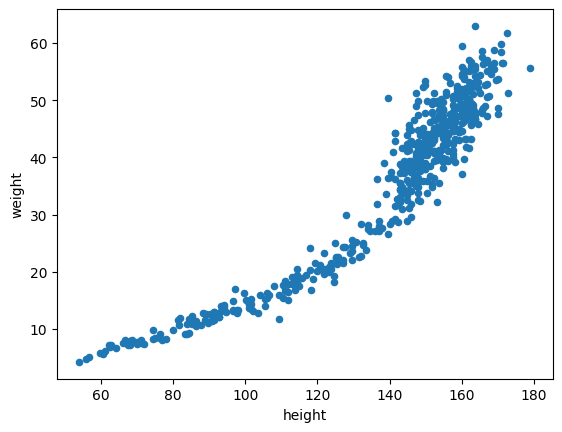

In [ ]:
howell.plot(x="height", y="weight", kind="scatter")

polynomial:

In [ ]:
model_poly_1 = bmb.Model("weight ~ poly(height, degree=4)", howell, family="negativebinomial")
idata_poly_1 = model_poly_1.fit()

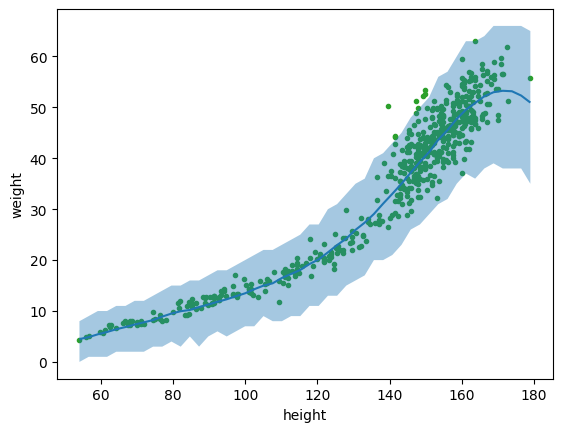

In [ ]:
bmb.interpret.plot_predictions(model_poly_1, idata_poly_1, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

B Splines:

In [ ]:
num_knots = 6
knots = np.linspace(howell.height.min(), howell.height.max(), num_knots+2)[1:-1]
model_spline = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell, family="negativebinomial")
idata_spline = model_spline.fit()

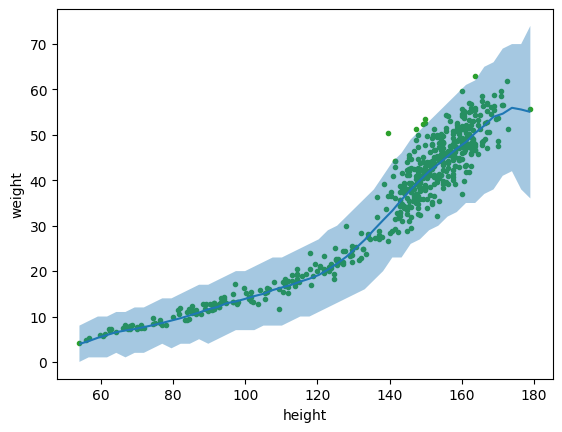

In [ ]:
bmb.interpret.plot_predictions(model_spline, idata_spline, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

Gaussian Process:

In [ ]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

weight = howell["weight"].values
height = howell["height"].values[:,None]

In [ ]:
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [ ]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[0, 24], lengthscale_range=[1, 30], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))


Recommended smallest number of basis vectors (m): 168
Recommended smallest scaling factor (c): 8.0


In [ ]:
with pm.Model() as model_hsgp:
    #prior for our smoothness parameter
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(height))

    #this is our kernal, which decides how our points relate to one another
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    #this specfices that we're using an HSGP
    gp = pm.gp.HSGP(m=[168], c=8.0, cov_func=cov)

    #f is for function, as in the function we use to transform our data
    f = gp.prior('f', X=height)
    #prior for the neg binomial
    α = pm.HalfNormal('α', 1)
    #likelihood
    y = pm.NegativeBinomial("y", np.exp(f), α, observed=weight)

    idata_hsgp = pm.sample()

Output()

/tmp/ipython-input-701/946507931.py:21: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pred = az.hdi(pred_weight.reshape(-1, pred_weight.shape[-1]), hdi_prob=0.95)


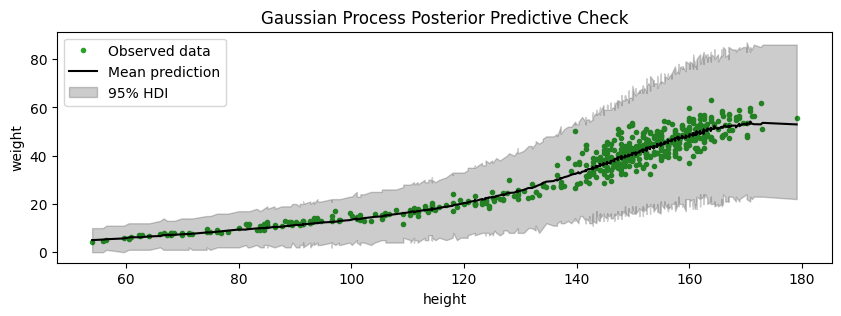

In [ ]:
# The original height from the model definition
model_height = howell["height"].values

# Sort height and corresponding predictions for plotting
# This ensures the plot lines connect correctly when height is not strictly increasing in the original data
sort_idx = np.argsort(model_height)
sorted_height = model_height[sort_idx]

# Generate posterior predictive samples
with model_hsgp:
    ppc = pm.sample_posterior_predictive(idata_hsgp, var_names=["y"])

# Extract predicted data and sort them according to sorted_height
# ppc.posterior_predictive["y"] has shape (chain, draw, data_point)
pred_weight = ppc.posterior_predictive["y"].values[:, :, sort_idx]

# Calculate mean and HDI for predictions across chains and draws
mean_pred = np.mean(pred_weight, axis=(0, 1))

# Reshape for az.hdi: combine chains and draws (first two dimensions), then apply to sorted data points
hdi_pred = az.hdi(pred_weight.reshape(-1, pred_weight.shape[-1]), hdi_prob=0.95)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(howell["height"].values, howell["weight"].values, "C2.", label="Observed data", zorder=-3)
ax.plot(sorted_height, mean_pred, "k-", label="Mean prediction")
ax.fill_between(sorted_height, hdi_pred[:, 0], hdi_pred[:, 1], color="k", alpha=0.2, label="95% HDI")
ax.set_xlabel("height")
ax.set_ylabel("weight")
ax.set_title("Gaussian Process Posterior Predictive Check")
ax.legend()
plt.show()

it wouldnt run so I used gemini to code for the predictive check.

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

gaussian processes use a mean of zero usually.

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

The CO2 vs year graph that haas the predictive guesses the line and the scatter plot data. I think its intresting because it is a good summary of the article.